In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('~/graduate-paper-code/spe1/csv_output.csv', sep=',')
df = df[df['well_type'] == 'INJ'].reset_index(drop=True)

df = df[['N_w', 'N_o', 'day', 'res_vol_inj']]


In [3]:
df

,N_w,N_o,day,res_vol_inj
0,1,1,31,2091.3
1,1,1,59,3958.4
2,1,1,90,5992.2
3,1,1,120,7928.4
4,1,1,151,9901.4
...,...,...,...,...
2995,5,5,3528,242516.6
2996,5,5,3558,245090.1
2997,5,5,3589,247756.0
2998,5,5,3619,250342.6


In [4]:
df.describe()

,N_w,N_o,day,res_vol_inj
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,3.000000,3.000000,1839.416667,117040.598667
std,1.414449,1.414449,1053.827394,72520.689691
min,1.000000,1.000000,31.000000,2090.000000
25%,2.000000,2.000000,934.250000,53894.625000
50%,3.000000,3.000000,1840.500000,110053.750000
75%,4.000000,4.000000,2743.750000,177658.225000
max,5.000000,5.000000,3650.000000,253502.300000


In [5]:
X = df[['N_w', 'N_o', 'day']]
y = df['res_vol_inj']

print('shape X - ', X.shape)
print('shape Y - ', y.shape)

# devide train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train.shape: ', X_train.shape)
print('X_train.shape: ', X_train.shape)
print('X_test.shape', X_test.shape)

# linear regression
print('LinearRegression() part')
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


shape X -  (3000, 3)
shape Y -  (3000,)
X_train.shape:  (2400, 3)
X_train.shape:  (2400, 3)
X_test.shape (600, 3)
LinearRegression() part


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear) 
r2_linear = r2_score(y_test, y_pred_linear)

print('linear reg results:')
print('linear model coeffs: ', linear_model.coef_)
print('MAE: ', mae_linear)
print('MSE: ',mse_linear)
print('RMSE: ', rmse_linear)
print('R^2: ', r2_linear)

# RandomForestRegressor
print('RandomForestRegressor')
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('random forest results:')
print('MAE: ', mean_absolute_error(y_test, y_pred_rf))
print('MSE: ',mean_squared_error(y_test, y_pred_rf))
print('RMSE: ', np.sqrt(mse_rf))
print('R^2: ', r2_score(y_test, y_pred_rf))

linear reg results:
linear model coeffs:  [-91.15966263 -49.22928686  68.6568113 ]
MAE:  5325.858518009037
MSE:  35632074.090102546
RMSE:  5969.260765798605
R^2:  0.9932331876524826
RandomForestRegressor
random forest results:
MAE:  2.3743866666781863
MSE:  25.864605036700663
RMSE:  5.085725615553858
R^2:  0.9999999950881072


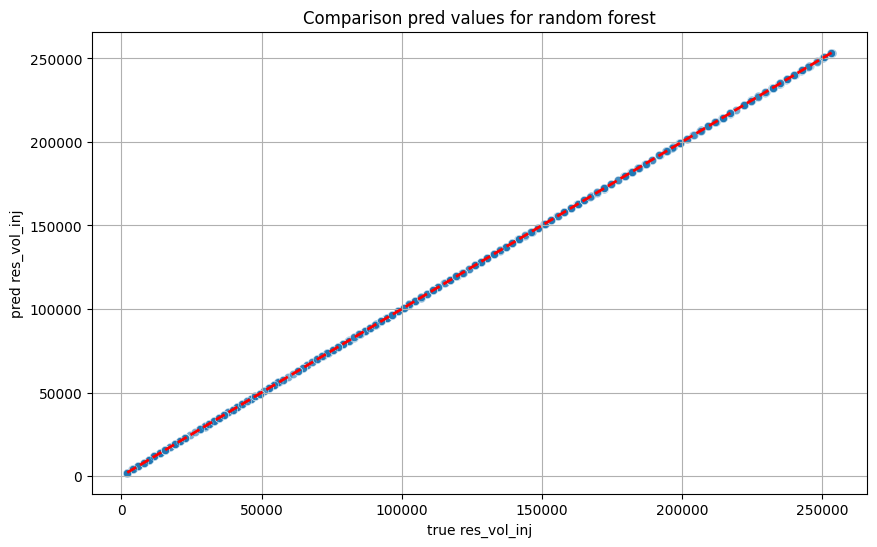

predict some values
new data: 
   N_w  N_o   day
0   15    5  1001
1    8    3  1002
2    2    1  1003
predicted res_vol_inj:
[57721.78  57690.503 57653.255]
Features importance
day    9.999992e-01
N_o    8.425217e-07
N_w    2.710103e-09
dtype: float64


In [7]:
# visualizing part for random forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("true res_vol_inj")
plt.ylabel("pred res_vol_inj")
plt.title('Comparison pred values for random forest')
plt.grid(True)
plt.show()

print('predict some values')
new_data_for_prediction = pd.DataFrame({
    'N_w': [15, 8, 2],
    'N_o': [5, 3, 1],
    'day': [1001, 1002, 1003]
})
predicted_res_vol_inj = random_forest_model.predict(new_data_for_prediction)

print(f'new data: \n{new_data_for_prediction}')
print(f'predicted res_vol_inj:\n{predicted_res_vol_inj}')

print('Features importance')
feature_importances = pd.Series(random_forest_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))
